In [ ]:
# !unzip "drive/MyDrive/Dog-Breed-Identification/dog-breed-identification.zip" -d  "drive/MyDrive/Dog-Breed-Identification"

## **Multi-class Dog breed classification using Tensorflow 2.0 and Tenserflow Hub**


1. **Problem**:
  Identifying the breed of a dog given an image of a dog

2. **Data**:
The data we're using is from kaggle's dog breed classification competition
https://www.kaggle.com/competitions/dog-breed-identification/data

* In this project i have dealt with images(unstructure data)
* There are 120 breeds of dogs
* There are 10,000 + images in training set (images have labels)
* There are 10,000 + images in test set (images are not labeled)


In [ ]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 5.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.preprocessing.image import img_to_array , load_img
from tensorflow.keras.applications import ResNet50V2, EfficientNetB0, InceptionV3
from tensorflow.keras.layers import Dense, Flatten, Dropout,Concatenate,Input, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.regularizers import l2, l1

import keras_tuner


print("tensorflow version : ", tf.__version__)
print("GPU" , "Accessed" if tf.config.list_physical_devices("GPU") else "Not Accessed")

tensorflow version :  2.18.0
GPU Accessed


# **Getting our data ready**
Convert images into tensors

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
label_csv = pd.read_csv("drive/MyDrive/Dog-Breed-Identification/labels.csv")

In [ ]:
label_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [ ]:
label_csv.describe()

,id,breed
count,10222,10222
unique,10222,120
top,fff43b07992508bc822f33d8ffd902ae,scottish_deerhound
freq,1,126


<Axes: xlabel='breed'>

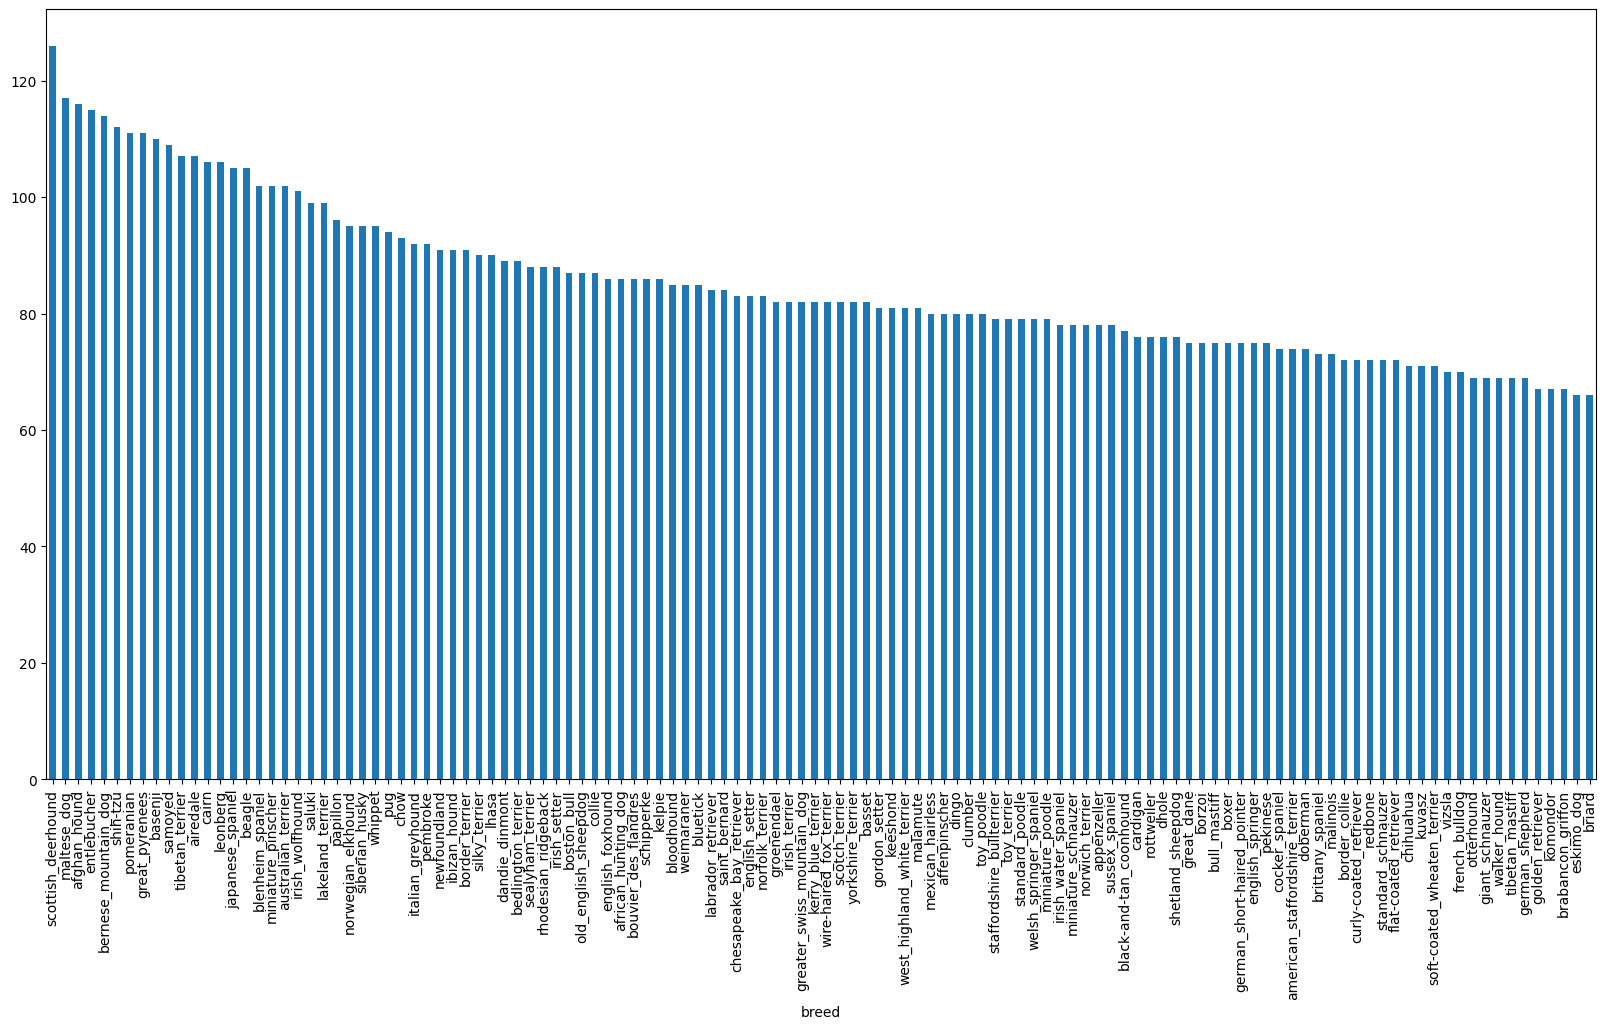

In [ ]:
label_csv["breed"].value_counts().plot.bar(figsize=(20,10))

In [ ]:
from IPython.display import Image
# Image("drive/MyDrive/Dog-Breed-Identification/train/000bec180eb18c7604dcecc8fe0dba07.jpg")

In [ ]:
paths = ["drive/MyDrive/Dog-Breed-Identification/train/" + id for id in label_csv["id"] + ".jpg"]

In [ ]:
# paths[:10]

In [ ]:
len(paths)

10222

In [ ]:
import os
if len(os.listdir("drive/MyDrive/Dog-Breed-Identification/train")) == len(paths):
  print("Number of images and number of labels are equal")
else:
  print("Path of all images of dog not recorded")

Number of images and number of labels are equal


In [ ]:
# Image(paths[8000])

In [ ]:
breed_list = label_csv["breed"].to_numpy()

In [ ]:
breed_list

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [ ]:

if len(breed_list) == len(paths):
  print("Number of labels and number of images are equal")
else :
  print("Some data is missing")

Number of labels and number of images are equal


In [ ]:
import numpy as np
unique_breeds = np.unique(breed_list)
len(unique_breeds)

120

In [ ]:
One_hot_breed = [breed == unique_breeds for breed in breed_list]
print(breed_list[0])
One_hot_breed[0]

boston_bull


array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [ ]:
len(One_hot_breed)

10222

In [ ]:
X  = paths
y = One_hot_breed

In [ ]:
NUM_IMAGES  = 10000 # @param {type:"slider", min:1000 , max:10000, step:1000}

I have only taken 1000 images for now and will increase as per needs

In [ ]:
## Creating validation split as it was not given
from sklearn.model_selection import train_test_split

X_train , X_val , y_train , y_val = train_test_split(X[:NUM_IMAGES], y[:NUM_IMAGES] , test_size=0.2, random_state=4)

len(X_train), len(y_train), len(X_val), len(y_val)

(8000, 8000, 2000, 2000)

#### Now i have made a function to preprocess images
* Takes image path as input
* Use tensorflow to read file and save it to `image`
* Turn `image` to tensor
* Normalize image(convert color channel from 0-255 to 0-1)
* Resize `image` to 224X224
* Return modified `image`

In [ ]:
IMG_SIZE = 224

# image to tensor
def preprocess_image(image_path):
  # read the image
  image = tf.io.read_file(image_path)

  #turn this image into numerical tensor
  image = tf.image.decode_jpeg(image, channels=3)

  #convert the color channel values from 0-255 to 0-1 values
  image = tf.image.convert_image_dtype(image, tf.float32)
  image = tf.image.resize(image , size=[IMG_SIZE , IMG_SIZE])
  return image

## Turning data into batches
Also we convert our data in form of tuples `(image , breed)`


In [ ]:
# This function return a tuple of image and breed
def get_image_breed(image_path, One_hot_breed):
  image = preprocess_image(image_path)
  return image , One_hot_breed

In [ ]:
# (preprocess_image(X[0]) , tf.constant(y[0]))

In [ ]:
BATCH_SIZE = 32
def create_data_batches(X, y = None , batch_size = BATCH_SIZE , valid_data = False , test_data = False):
  if test_data:
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X)))
    data_batch = data.map(preprocess_image).batch(BATCH_SIZE)

  elif valid_data:
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X), tf.constant(y)))
    data_batch = data.map(get_image_breed).batch(BATCH_SIZE)
  else :
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X) , tf.constant(y)))
    data = data.shuffle(buffer_size=len(X))
    data = data.map(get_image_breed)
    data_batch = data.batch(BATCH_SIZE)
  return data_batch

In [ ]:
train_data = create_data_batches(X_train , y_train)
val_data = create_data_batches(X_val , y_val, valid_data = True)

In [ ]:
train_data.element_spec

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))

## **Visualizing Data Batches**

In [ ]:
import matplotlib.pyplot as plt
def show_images(images , One_hot_breed):
  plt.figure(figsize=(15,10))
  for i in range(20):
    ax = plt.subplot(4, 5, i+1)
    plt.imshow(images[i])
    plt.title(unique_breeds[np.argmax(One_hot_breed[i])])
    plt.axis("off")

In [ ]:
# train_image , train_breed = next(train_data.as_numpy_iterator())
# show_images(train_image , train_breed)

In [ ]:
# val_image , val_breed = next(val_data.as_numpy_iterator())
# show_images(val_image , val_breed)

# Creating Callbacks

In [ ]:
# import datetime
# def create_tensorboard_callback():
#   logdir = os.path.join("drive/MyDrive/Dog-Breed-Identification/log", datetime.datetime.now().strftime("%y%m%d-%H%M%S"))
#   return tf.keras.callbacks.TensorBoard(logdir)

In [ ]:
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
## Early Stopping Callback
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=7)

In [ ]:
# Training model
NUM_EPOCHS = 150 # @param {type:"slider", min:10, max:500, step:10}


## **PreTrained Models**

In [ ]:
# base_model = InceptionV3(
#     include_top=False,
#     weights="imagenet",
#     input_shape=(IMG_SIZE, IMG_SIZE, 3),
#     pooling="avg",
#     name="inceptionV3",
#     )
# for layer in base_model.layers:
#       layer.trainable = False
# for layer in base_model.layers[-10:]:
#       layer.trainable = True
# base_model.summary()

# Using ResNet50V2 only as base model

In [ ]:
# def build_model(hp):

#     base_model = ResNet50V2(
#     include_top=False,
#     weights="imagenet",
#     input_shape=(IMG_SIZE, IMG_SIZE, 3),
#     pooling="avg",
#     name="resnet50v2",
#     )
#     for layer in base_model.layers:
#       layer.trainable = False
#     for layer in base_model.layers[-10:]:
#       layer.trainable = True

#     model = Sequential()
#     model.add(base_model)

#     # if hp.Boolean("dropout_base"):
#     #     model.add(Dropout(rate=hp.Float("dropout_rate_base", 0.3, 0.7)))

#     for i in range(hp.Int("num_layers", 1, 4)):
#         if hp.Boolean(f"dropout_{i}"):
#             model.add(Dropout(rate=hp.Float(f"dropout_rate-{i}", 0.4, 0.7)))
#         model.add(
#             Dense(
#                 # Tune number of units separately.
#                 units=hp.Int(f"units_{i}", min_value=384, max_value=1024, step=32),
#                 activation=hp.Choice("activation", ["relu"]),
#                 kernel_regularizer=tf.keras.regularizers.l2(hp.Float(f"l2_{i}", 1e-4, 1e-3))
#             )
#         )



#     model.add(Dense(len(unique_breeds), activation="softmax"))

#     learning_rate = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")

#     model.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
#         loss="categorical_crossentropy",
#         metrics=["accuracy"],
#     )
#     return model

# build_model(keras_tuner.HyperParameters())

In [ ]:
# tuner = keras_tuner.RandomSearch(
#     hypermodel=build_model,
#     objective="val_accuracy",
#     max_trials=3,
#     overwrite=True,
#     directory="my_dir",
#     project_name="trial1",
# )

# tuner.search_space_summary()

In [ ]:
# tuner.search(x = train_data , epochs=NUM_EPOCHS, validation_data=val_data, callbacks=[early_stopping, reduce_lr])

# **Tuning number of layers and neurons in it**

In [ ]:
## creating a base model from pretrained models
def create_base_model(model_type, trainable_layers):
    """Creates and configures a base pretrained model."""
    if model_type == "ResNet50V2":
        base_model = ResNet50V2(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            pooling="avg",
        )
    elif model_type == "EfficientNetB0":
        base_model = EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            pooling="avg",
        )
    elif model_type == "InceptionV3":
        base_model = InceptionV3(
            include_top=False,
            weights="imagenet",
            input_shape=(IMG_SIZE, IMG_SIZE, 3),
            pooling="avg",
        )
    else:
        raise ValueError("Invalid model type")

    # Freeze all layers
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze the last `trainable_layers`
    for layer in base_model.layers[-trainable_layers:]:
        layer.trainable = True

    return base_model


In [ ]:
## combining the features from each pretrained model
def combine_model_features(models):
    """Combines features from multiple base models."""
    combined_features = Concatenate()(models)
    return combined_features

# **Tuning number of layers and neurons in it**

In [ ]:
## Adding dense layer(cofiguring num of layers and neurons in each layer only)
# def add_dense_layers(x, hp):
#     """Adds dense layers with decreasing or equal number of neurons."""

#     prev_units = None
#     for i in range(hp.Int("num_layers", 1, 4)):
#         # Set the max units for the current layer based on the previous layer's units
#         max_units = prev_units if prev_units is not None else 1024

#         units = hp.Int(f"units_{i}", min_value=384, max_value=max_units, step=32)
#         x = Dense(units=units, activation="relu")(x)

#         # Update prev_units for the next iteration
#         prev_units = units

#     return x


In [ ]:
## Blue print of the model
def build_model(hp):
    """Builds the complete model with multiple pretrained models."""
    # Input layer
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Create base models
    resnet_model = create_base_model("ResNet50V2", trainable_layers=15)(inputs)
    efficientnet_model = create_base_model("EfficientNetB0", trainable_layers=15)(inputs)
    inception_model = create_base_model("InceptionV3", trainable_layers=15)(inputs)

    # Combine features from all models
    combined_features = combine_model_features(
        [resnet_model, efficientnet_model, inception_model]
    )

    combined_features = BatchNormalization()(combined_features)
    # Add dense layers
    x = add_dense_layers(combined_features, hp)

    # Output layer
    outputs = Dense(len(unique_breeds), activation="softmax")(x)

    # Build and compile the model
    model = Model(inputs=inputs, outputs=outputs)
    model = compile_model(model, hp)

    return model

In [ ]:
# ## Model compling
def compile_model(model, hp):
    """Compiles the model with the selected learning rate."""
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [ ]:
# hp = keras_tuner.HyperParameters()
# model = build_model(hp)

In [ ]:
# tuner = keras_tuner.RandomSearch(
#     hypermodel=build_model,
#     objective="val_accuracy",
#     max_trials=8,
#     overwrite=False,
#     directory="drive/MyDrive/Dog-Breed-Identification",
#     project_name="trialsWithNonIncNeuronNum",
# )

# tuner.search_space_summary()

Reloading Tuner from drive/MyDrive/Dog-Breed-Identification/trialsWithNonIncNeuronNum/tuner0.json
Search space summary
Default search space size: 5
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 384, 'max_value': 1024, 'step': 32, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 384, 'max_value': 992, 'step': 32, 'sampling': 'linear'}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 384, 'max_value': 384, 'step': 32, 'sampling': 'linear'}
units_3 (Int)
{'default': None, 'conditions': [], 'min_value': 384, 'max_value': 384, 'step': 32, 'sampling': 'linear'}


In [ ]:
# tuner.search(x = train_data , epochs=NUM_EPOCHS, validation_data=val_data, callbacks=[early_stopping, reduce_lr])

Trial 8 Complete [00h 18m 27s]
val_accuracy: 0.7250000238418579

Best val_accuracy So Far: 0.737500011920929
Total elapsed time: 20h 32m 27s


In [ ]:
# tuner.results_summary()

Results summary
Results in drive/MyDrive/Dog-Breed-Identification/trialsWithNonIncNeuronNum
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 6 summary
Hyperparameters:
num_layers: 4
units_0: 704
units_1: 384
units_2: 384
units_3: 384
Score: 0.737500011920929

Trial 7 summary
Hyperparameters:
num_layers: 1
units_0: 960
units_1: 896
units_2: 384
units_3: 384
Score: 0.7250000238418579

Trial 0 summary
Hyperparameters:
num_layers: 2
units_0: 992
units_1: 384
Score: 0.6875

Trial 1 summary
Hyperparameters:
num_layers: 4
units_0: 704
units_1: 384

Trial 5 summary
Hyperparameters:
num_layers: 3
units_0: 704
units_1: 576
units_2: 384
units_3: 384

Trial 2 summary
Hyperparameters:
num_layers: 1
units_0: 960
units_1: 896
units_2: 384
units_3: 384

Trial 3 summary
Hyperparameters:
num_layers: 4
units_0: 704
units_1: 416
units_2: 384
units_3: 384

Trial 4 summary
Hyperparameters:
num_layers: 4
units_0: 960
units_1: 736
units_2: 384
units_3: 384


In [ ]:
# tuner.get_best_hyperparameters()[0]

# Adding dropouts to decrease overfitting with num of layers and neuron count based on prev result


In [ ]:
def add_dense_layers(x, hp):
    """Adds dense layers based on hyperparameters."""

    available_units = [512, 712, 864, 1024]
    prev_max_units = max(available_units)
    for i in range(hp.Int("num_layers", 1, 3)):
        x = Dropout(rate=hp.Choice(f"dropout_rate_{i}", [0.3,0.4,0.5]))(x)

        filtered_units = [u for u in available_units if u <= prev_max_units]
        units = hp.Choice(f"units_{i}", filtered_units)
        x = Dense(
            units=units,
            activation="relu",
        )(x)
        prev_max_units = units

    return x

In [ ]:
hp = keras_tuner.HyperParameters()
model = build_model(hp)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=5,
    overwrite=False,
    directory="drive/MyDrive/Dog-Breed-Identification",
    project_name="trials_dropouts",
)

tuner.search_space_summary()

Reloading Tuner from drive/MyDrive/Dog-Breed-Identification/trials_dropouts/tuner0.json
Search space summary
Default search space size: 3
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
dropout_rate_0 (Choice)
{'default': 0.3, 'conditions': [], 'values': [0.3, 0.4, 0.5], 'ordered': True}
units_0 (Choice)
{'default': 512, 'conditions': [], 'values': [512, 712, 864, 1024], 'ordered': True}


In [ ]:
tuner.search(x = train_data , epochs=NUM_EPOCHS, validation_data=val_data, callbacks=[early_stopping, reduce_lr])

Trial 5 Complete [02h 57m 23s]
val_accuracy: 0.737500011920929

Best val_accuracy So Far: 0.7400000095367432
Total elapsed time: 1d 06h 22m 59s


### Learning(0.01) for trial 1, 2, 3 is large as per the performance after certain Epoch

In [ ]:
tuner.results_summary()

Results summary
Results in drive/MyDrive/Dog-Breed-Identification/trials_dropouts
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 3 summary
Hyperparameters:
num_layers: 2
dropout_rate_0: 0.4
units_0: 864
dropout_rate_1: 0.5
units_1: 512
dropout_rate_2: 0.4
units_2: 512
Score: 0.7400000095367432

Trial 4 summary
Hyperparameters:
num_layers: 1
dropout_rate_0: 0.5
units_0: 1024
dropout_rate_1: 0.4
units_1: 712
dropout_rate_2: 0.3
units_2: 512
Score: 0.737500011920929

Trial 1 summary
Hyperparameters:
num_layers: 1
dropout_rate_0: 0.4
units_0: 512
Score: 0.7250000238418579

Trial 2 summary
Hyperparameters:
num_layers: 3
dropout_rate_0: 0.3
units_0: 864
dropout_rate_1: 0.3
units_1: 512
dropout_rate_2: 0.3
units_2: 512
Score: 0.7225000262260437

Trial 0 summary
Hyperparameters:
num_layers: 1
dropout_rate_0: 0.3
units_0: 1024
Score: 0.7124999761581421


# Saving the top 3 hyperparameters

In [ ]:
import pickle

# Save the best hyperparameters to a file
with open('/content/drive/MyDrive/Dog-Breed-Identification/model_saved/trials_dropout_best_hps.pkl', 'wb') as f:
    pickle.dump(tuner.get_best_hyperparameters(num_trials=3), f)

# Extracting top_hps from the saved hps

In [ ]:
with open('/content/drive/MyDrive/Dog-Breed-Identification/model_saved/trials_dropout_best_hps.pkl', 'rb') as f:
    top_hps = pickle.load(f)

# Including L2 regularisation as well

In [ ]:
# def modify_with_regularization(hp, reg_lambda_range=(1e-6, 1e-2), reg_type="l2"):
#     """Modifies hyperparameters to include regularization with log-sampling."""
#     modified_hp = hp.copy()
#     # Logarithmic sampling for reg_lambda
#     log_min, log_max = np.log10(reg_lambda_range[0]), np.log10(reg_lambda_range[1])
#     reg_lambda = 10 ** np.random.uniform(log_min, log_max)

#     modified_hp["reg_lambda"] = reg_lambda
#     modified_hp["reg_type"] = reg_type

#     return modified_hp

# def recreate_hp_from_dict(hp_dict):
#     """Recreates a HyperParameters object from a dictionary."""
#     hp = keras_tuner.HyperParameters()
#     for name, value in hp_dict.items():
#         print("name", name)
#         print("value",value)
#         if isinstance(value, (int, float, str, bool)):
#             hp.Fixed(name, value)
#         # You may need additional handling for other types (like hp.Choice)
#         elif isinstance(value, list):
#             hp.Choice(name, value)
#     return hp

# # Now rebuild the top_hps list with HyperParameters objects:
# top_hps_with_reg = [recreate_hp_from_dict(modify_with_regularization(hp_dict))
#                      for hp_dict in top_hps]


{}
name reg_lambda
value 1.0961217079859373e-06
name reg_type
value l2
{}
name reg_lambda
value 3.6239369214773375e-05
name reg_type
value l2
{}
name reg_lambda
value 0.00027745250493295496
name reg_type
value l2


In [ ]:

# Checking

# for i, hp in enumerate(top_hps_with_reg):
#     print(f"Building model {i+1} with regularization")
#     print(f"Type of hp: {type(hp)}")  # Check the type of hp
#     if not isinstance(hp, keras_tuner.HyperParameters):
#         raise TypeError(f"Expected HyperParameters object, got {type(hp)} instead")

#     model = build_model(hp)
#     models_with_reg.append(model)


In [ ]:
def add_dense_layers(x, hp):
    """Adds dense layers based on hyperparameters."""

    available_units = [512, 712, 864, 1024]
    prev_max_units = max(available_units)
    if "num_layers" in hp.values:
        num_layers = hp.get("num_layers")
        print("hp has num layers as ", num_layers)
    else:
        num_layers = 2  # Fallback default value
        print("hp has no num layers as ", num_layers)


    for i in range(num_layers):
        x = Dropout(rate=hp.Choice(f"dropout_rate_{i}", [0.3, 0.4, 0.5]))(x)

        filtered_units = [u for u in available_units if u <= prev_max_units]

        units = hp.Choice(f"units_{i}", filtered_units)

        # Get regularization parameters from hyperparameters
        reg_lambda = hp.get("reg_lambda") if "reg_lambda" in hp.values else 0.0
        reg_type = hp.get("reg_type") if "reg_type" in hp.values else "l2"
        print("reg_lambda" ,reg_lambda)
        print("reg_type", reg_type)

        regularizer = l1(reg_lambda) if reg_type == "l1" else l2(reg_lambda)

        x = Dense(
            units=units,
            activation="relu",
            kernel_regularizer=regularizer  # Apply the regularizer
        )(x)

        prev_max_units = units

    return x


# Building Model

In [ ]:
top_hps_with_reg

In [ ]:
models_with_reg = []
for i, hp in enumerate(top_hps_with_reg):
    print(f"Building model {i+1} with regularization")
    print(i, end=" ")
    print(hp)
    if not isinstance(hp, keras_tuner.HyperParameters):
        raise TypeError(f"Expected HyperParameters object, got {type(hp)} instead")

    model = build_model(hp)
    models_with_reg.append(model)

Building model 1 with regularization
0 <keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters object at 0x7f9128b82d90>
hp has no num layers as  2
reg_lambda 1.8307028382555633e-05
reg_type l2
reg_lambda 1.8307028382555633e-05
reg_type l2
Building model 2 with regularization
1 <keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters object at 0x7f9141987e90>
hp has no num layers as  2
reg_lambda 0.00012575749779930397
reg_type l2
reg_lambda 0.00012575749779930397
reg_type l2
Building model 3 with regularization
2 <keras_tuner.src.engine.hyperparameters.hyperparameters.HyperParameters object at 0x7f91881be0d0>
hp has no num layers as  2
reg_lambda 0.0010353473280303093
reg_type l2
reg_lambda 0.0010353473280303093
reg_type l2


## From scratch with regularization(L2)

In [ ]:
def add_dense_layers(x, hp):
    """Adds dense layers based on hyperparameters."""

    available_units = [512, 712, 864, 1024]
    prev_max_units = max(available_units)
    num_layers = hp.Int("num_layers", 1, 3)
    print(num_layers)


    for i in range(num_layers):
        x = Dropout(rate=hp.Choice(f"dropout_rate_{i}", [0.4, 0.5]))(x)
        filtered_units = [u for u in available_units if u <= prev_max_units]

        units = hp.Choice(f"units_{i}", filtered_units)

        # Get regularization parameters from hyperparameters
        reg_lambda = hp.Float(f"reg_lambda{i}", min_value=1e-6, max_value=1e-3, sampling="log")
        print(f"reg_lambda{i}" ,reg_lambda)

        regularizer = l2(reg_lambda)

        x = Dense(
            units=units,
            activation="relu",
            kernel_regularizer=regularizer  # Apply the regularizer
        )(x)

        prev_max_units = units

    return x


In [ ]:
hp = keras_tuner.HyperParameters()
model = build_model(hp)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1
reg_lambda0 1e-06


In [ ]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=12,
    overwrite=False,
    directory="drive/MyDrive/Dog-Breed-Identification",
    project_name="final_model_0.1",
)

tuner.search_space_summary()

Reloading Tuner from drive/MyDrive/Dog-Breed-Identification/final_model_0.1/tuner0.json
Search space summary
Default search space size: 10
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
dropout_rate_0 (Choice)
{'default': 0.4, 'conditions': [], 'values': [0.4, 0.5], 'ordered': True}
units_0 (Choice)
{'default': 512, 'conditions': [], 'values': [512, 712, 864, 1024], 'ordered': True}
reg_lambda0 (Float)
{'default': 1e-06, 'conditions': [], 'min_value': 1e-06, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
dropout_rate_1 (Choice)
{'default': 0.4, 'conditions': [], 'values': [0.4, 0.5], 'ordered': True}
units_1 (Choice)
{'default': 512, 'conditions': [], 'values': [512, 712, 864, 1024], 'ordered': True}
reg_lambda1 (Float)
{'default': 1e-06, 'conditions': [], 'min_value': 1e-06, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
dropout_rate_2 (Choice)
{'default': 0.4, 'conditions': [], 'values': [0.4, 0.5], 'o

In [ ]:
tuner.search(x = train_data , epochs=NUM_EPOCHS, validation_data=val_data, callbacks=[early_stopping, reduce_lr])

Trial 12 Complete [00h 08m 02s]
val_accuracy: 0.7300000190734863

Best val_accuracy So Far: 0.7549999952316284
Total elapsed time: 03h 17m 05s


## Best parameters are -


*   num_layers : 3
*   dropout_rate_0: 0.4
*   units_0: 864
*   reg_lambda0 : 0.0007041034099077888
*   dropout_rate_1 : 0.5
*   units_1 : 1024
*   reg_lambda1 : 0.00012899061286214344
*   dropout_rate_2 : 0.4
*   units_2 : 512
*   reg_lambda2 : 1e-06



In [ ]:
## Blue print of the model
def build_model():
    """Builds the complete model with multiple pretrained models."""
    # Input layer
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Create base models
    resnet_model = create_base_model("ResNet50V2", trainable_layers=15)(inputs)
    efficientnet_model = create_base_model("EfficientNetB0", trainable_layers=15)(inputs)
    inception_model = create_base_model("InceptionV3", trainable_layers=15)(inputs)

    # Combine features from all models
    combined_features = combine_model_features(
        [resnet_model, efficientnet_model, inception_model]
    )

    combined_features = BatchNormalization()(combined_features)
    # Add dense layers
    x = add_dense_layers(combined_features)

    # Output layer
    outputs = Dense(len(unique_breeds), activation="softmax")(x)

    # Build and compile the model
    model = Model(inputs=inputs, outputs=outputs)
    model = compile_model(model)

    return model

In [ ]:
def compile_model(model):
    """Compiles the model with the chosen optimizer and loss function."""
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),  # Choose a final LR
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


In [ ]:
def add_dense_layers(x):
    """ Using tuned parameters for final training"""

    dropout_rates = [0.4 , 0.5, 0.4]
    num_layers = [864 , 1024, 512]
    reg_lambdas = [0.0007041034099077888 , 0.00012899061286214344, 1e-06]

    for i in range(3):
        print("Layer num -" , i)
        print("dropout_rate -", dropout_rates[i])
        print("reg_lambdas -", reg_lambdas[i])
        print("num_layers-units -",num_layers[i])

        x = Dropout(dropout_rates[i])(x)
        units = num_layers[i]
        reg_lambda = reg_lambdas[i]
        regularizer = l2(reg_lambda)

        x = Dense(
            units=units,
            activation="relu",
            kernel_regularizer=regularizer  # Apply the regularizer
        )(x)

    return x

In [ ]:
# Build the final model with the best hyperparameters
final_model = build_model()

Layer num - 0
dropout_rate - 0.4
reg_lambdas - 0.0007041034099077888
num_layers-units - 864
Layer num - 1
dropout_rate - 0.5
reg_lambdas - 0.00012899061286214344
num_layers-units - 1024
Layer num - 2
dropout_rate - 0.4
reg_lambdas - 1e-06
num_layers-units - 512


In [ ]:
history = final_model.fit(
        x=train_data,
        epochs=NUM_EPOCHS,
        validation_data=val_data,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

Epoch 1/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 1819s 7s/step - accuracy: 0.2187 - loss: 5.0534 - val_accuracy: 0.6640 - val_loss: 2.6770 - learning_rate: 0.0010
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 222ms/step - accuracy: 0.6291 - loss: 2.7923 - val_accuracy: 0.7045 - val_loss: 2.4648 - learning_rate: 0.0010
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 93s 265ms/step - accuracy: 0.7014 - loss: 2.4995 - val_accuracy: 0.7305 - val_loss: 2.3575 - learning_rate: 0.0010
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 264ms/step - accuracy: 0.7315 - loss: 2.2964 - val_accuracy: 0.7395 - val_loss: 2.3292 - learning_rate: 0.0010
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 72s 224ms/step - accuracy: 0.7531 - loss: 2.1798 - val_accuracy: 0.7490 - val_loss: 2.2367 - learning_rate: 0.0010
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 223ms/step - accuracy: 0.7730 - loss: 2.0938 - val_accuracy: 0.7595 - val_loss: 2.2243 - learning_rate: 0.0010
Epoch 7/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 224ms/step - accurac

In [ ]:
def add_dense_layers(x):
    """ Using tuned parameters for final training"""

    dropout_rates = [0.5]
    num_layers = [512]
    reg_lambdas = [0.0007041034099077888]

    for i in range(1):
        print("Layer num -" , i)
        print("dropout_rate -", dropout_rates[i])
        print("reg_lambdas -", reg_lambdas[i])
        print("num_layers-units -",num_layers[i])

        x = Dropout(dropout_rates[i])(x)
        units = num_layers[i]
        reg_lambda = reg_lambdas[i]
        regularizer = l2(reg_lambda)

        x = Dense(
            units=units,
            activation="relu",
            kernel_regularizer=regularizer  # Apply the regularizer
        )(x)

    return x

In [ ]:
# Build the final model with the best hyperparameters
final_model = build_model()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Layer num - 0
dropout_rate - 0.5
reg_lambdas - 0.0007041034099077888
num_layers-units - 512


In [ ]:
history = final_model.fit(
        x=train_data,
        epochs=NUM_EPOCHS,
        validation_data=val_data,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

Epoch 1/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 2488s 10s/step - accuracy: 0.4895 - loss: 3.3631 - val_accuracy: 0.6275 - val_loss: 2.8864 - learning_rate: 0.0010
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 216ms/step - accuracy: 0.7787 - loss: 1.7949 - val_accuracy: 0.6670 - val_loss: 2.6376 - learning_rate: 0.0010
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 219ms/step - accuracy: 0.8513 - loss: 1.4688 - val_accuracy: 0.6840 - val_loss: 2.7518 - learning_rate: 0.0010
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.8731 - loss: 1.3407
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 223ms/step - accuracy: 0.8731 - loss: 1.3408 - val_accuracy: 0.6500 - val_loss: 2.9945 - learning_rate: 0.0010
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 81s 221ms/step - accuracy: 0.9189 - loss: 1.1784 - val_accuracy: 0.7870 - val_loss: 1.8327 - learning_rate: 2.0000e-04
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 81s 219ms/step - accu

In [ ]:
def add_dense_layers(x):
    """ Using tuned parameters for final training"""

    dropout_rates = [0.5, 0.4]
    num_layers = [1024, 512]
    reg_lambdas = [1.0342590672055833e-05, 1e-06]

    for i in range(2):
        print("Layer num -" , i)
        print("dropout_rate -", dropout_rates[i])
        print("reg_lambdas -", reg_lambdas[i])
        print("num_layers-units -",num_layers[i])

        x = Dropout(dropout_rates[i])(x)
        units = num_layers[i]
        reg_lambda = reg_lambdas[i]
        regularizer = l2(reg_lambda)

        x = Dense(
            units=units,
            activation="relu",
            kernel_regularizer=regularizer  # Apply the regularizer
        )(x)

    return x

In [ ]:
# Build the final model with the best hyperparameters
final_model = build_model()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Layer num - 0
dropout_rate - 0.5
reg_lambdas - 1.0342590672055833e-05
num_layers-units - 1024
Layer num - 1
dropout_rate - 0.4
reg_lambdas - 1e-06
num_layers-units - 512


In [ ]:
history = final_model.fit(
        x=train_data,
        epochs=NUM_EPOCHS,
        validation_data=val_data,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

Epoch 1/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 2444s 10s/step - accuracy: 0.3858 - loss: 2.9554 - val_accuracy: 0.7245 - val_loss: 1.0761 - learning_rate: 0.0010
Epoch 2/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 64s 222ms/step - accuracy: 0.7236 - loss: 1.0139 - val_accuracy: 0.7350 - val_loss: 1.0445 - learning_rate: 0.0010
Epoch 3/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 219ms/step - accuracy: 0.7795 - loss: 0.8067 - val_accuracy: 0.7035 - val_loss: 1.2362 - learning_rate: 0.0010
Epoch 4/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.7994 - loss: 0.7029
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 218ms/step - accuracy: 0.7993 - loss: 0.7030 - val_accuracy: 0.7355 - val_loss: 1.0548 - learning_rate: 0.0010
Epoch 5/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 218ms/step - accuracy: 0.8661 - loss: 0.4505 - val_accuracy: 0.7865 - val_loss: 0.9067 - learning_rate: 2.0000e-04
Epoch 6/150
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 219ms/step - accu

KeyboardInterrupt: 

In [ ]:
import os

model_save_dir = '/content/drive/MyDrive/Dog-Breed-Identification/saved_models/subset'
os.makedirs(model_save_dir, exist_ok=True)

In [ ]:
# Set appropriate epochs
for i, model in enumerate(models_with_reg):
    print(f"Training model {i+1}")

    # Compile the model if it hasn't been already compiled
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    # Train the model
    history = model.fit(
        x=train_data,
        epochs=NUM_EPOCHS,
        validation_data=val_data,
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    model_save_path = os.path.join(model_save_dir, f'model_{i+1}.h5')
    model.save(model_save_path)
    print(f"Model {i+1} saved at {model_save_path}")


Training model 1
Epoch 1/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 502s 9s/step - accuracy: 0.1845 - loss: 4.3622 - val_accuracy: 0.3125 - val_loss: 3.1552 - learning_rate: 0.0010
Epoch 2/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 40s 224ms/step - accuracy: 0.7018 - loss: 1.0754 - val_accuracy: 0.4800 - val_loss: 2.0602 - learning_rate: 0.0010
Epoch 3/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.8230 - loss: 0.6144 - val_accuracy: 0.6325 - val_loss: 1.3014 - learning_rate: 0.0010
Epoch 4/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 206ms/step - accuracy: 0.8987 - loss: 0.3963 - val_accuracy: 0.6275 - val_loss: 1.5835 - learning_rate: 0.0010
Epoch 5/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9329 - loss: 0.2602
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 227ms/step - accuracy: 0.9327 - loss: 0.2607 - val_accuracy: 0.6800 - val_loss: 1.3113 - learning_rate: 0.0010
Epoch 6/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 214ms/step - accuracy: 0.9

Model 1 saved at /content/drive/MyDrive/Dog-Breed-Identification/saved_models/subset/model_1.h5
Training model 2
Epoch 1/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.1864 - loss: 4.4101 - val_accuracy: 0.3925 - val_loss: 2.6587 - learning_rate: 0.0010
Epoch 2/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 208ms/step - accuracy: 0.6947 - loss: 1.2535 - val_accuracy: 0.5425 - val_loss: 1.9819 - learning_rate: 0.0010
Epoch 3/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 229ms/step - accuracy: 0.8369 - loss: 0.8018 - val_accuracy: 0.6300 - val_loss: 1.7534 - learning_rate: 0.0010
Epoch 4/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 217ms/step - accuracy: 0.8713 - loss: 0.6377 - val_accuracy: 0.6650 - val_loss: 1.5165 - learning_rate: 0.0010
Epoch 5/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 245ms/step - accuracy: 0.9449 - loss: 0.4117 - val_accuracy: 0.7050 - val_loss: 1.4341 - learning_rate: 0.0010
Epoch 6/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 229ms/step - accuracy: 0.9458 - loss: 0.3893 - val_accuracy: 0.7050 - val_loss: 1.

Model 2 saved at /content/drive/MyDrive/Dog-Breed-Identification/saved_models/subset/model_2.h5
Training model 3
Epoch 1/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.1967 - loss: 5.8255 - val_accuracy: 0.2650 - val_loss: 4.5970 - learning_rate: 0.0010
Epoch 2/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 71s 216ms/step - accuracy: 0.7074 - loss: 2.6637 - val_accuracy: 0.4950 - val_loss: 3.5569 - learning_rate: 0.0010
Epoch 3/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 220ms/step - accuracy: 0.8260 - loss: 2.1969 - val_accuracy: 0.6600 - val_loss: 2.9116 - learning_rate: 0.0010
Epoch 4/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 220ms/step - accuracy: 0.8985 - loss: 1.9475 - val_accuracy: 0.6725 - val_loss: 2.8451 - learning_rate: 0.0010
Epoch 5/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 215ms/step - accuracy: 0.9280 - loss: 1.8687 - val_accuracy: 0.6925 - val_loss: 2.7833 - learning_rate: 0.0010
Epoch 6/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 220ms/step - accuracy: 0.9498 - loss: 1.7287 - val_accuracy: 0.6575 - val_loss: 3.

Model 3 saved at /content/drive/MyDrive/Dog-Breed-Identification/saved_models/subset/model_3.h5


In [ ]:
def add_dense_layers(x, hp):
    """Adds dense layers based on hyperparameters."""
    if hp.Boolean("dropout_combined"):
        x = Dropout(rate=hp.Float("dropout_rate_combined", 0.4, 0.7))(x)

    for i in range(hp.Int("num_layers", 1, 4)):
        x = Dense(
            units=hp.Int(f"units_{i}", min_value=284, max_value=1024, step=32),
            activation=hp.Choice("activation", ["relu"]),
            kernel_regularizer=l2(hp.Float(f"l2_{i}", 1e-4, 1e-3)),
        )(x)
        if hp.Boolean(f"dropout_{i}"):
            x = Dropout(rate=hp.Float(f"dropout_rate_{i}", 0.35, 0.8))(x)
    return x


def compile_model(model, hp):
    """Compiles the model with the selected learning rate."""
    learning_rate = hp.Float("lr", min_value=1e-4, max_value=1e-2, sampling="log")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_model(hp):
    """Builds the complete model with multiple pretrained models."""
    # Input layer
    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Create base models
    resnet_model = create_base_model("ResNet50V2", trainable_layers=15)(inputs)
    efficientnet_model = create_base_model("EfficientNetB0", trainable_layers=15)(inputs)
    inception_model = create_base_model("InceptionV3", trainable_layers=15)(inputs)

    # Combine features from all models
    combined_features = combine_model_features(
        [resnet_model, efficientnet_model, inception_model]
    )

    combined_features = BatchNormalization()(combined_features)
    # Add dense layers
    x = add_dense_layers(combined_features, hp)

    # Output layer
    outputs = Dense(len(unique_breeds), activation="softmax")(x)

    # Build and compile the model
    model = Model(inputs=inputs, outputs=outputs)
    model = compile_model(model, hp)

    return model

hp = keras_tuner.HyperParameters()
model = build_model(hp)


In [ ]:
tuner = keras_tuner.RandomSearch(
    hypermodel=build_model,
    objective="val_accuracy",
    max_trials=15,
    overwrite=False,
    directory="drive/MyDrive/Dog-Breed-Identification",
    project_name="trials",
)

tuner.search_space_summary()

In [ ]:
tuner.search(x = train_data , epochs=NUM_EPOCHS, validation_data=val_data, callbacks=[early_stopping, reduce_lr])

In [ ]:
models = tuner.get_best_models(num_models=2)
best_model = models[0]
best_model.summary()

In [ ]:
best_model2 = models[1]
best_model2.summary()

#### Visualizing TensorBoard logs

In [ ]:
%tensorboard --logdir drive/MyDrive/Dog-Breed-Identification/logs

In [ ]:
## Model Predictions
prediction = model.predict(val_data, verbose=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 440ms/step


In [ ]:
np.max(prediction[0]), np.argmax(prediction[0]), unique_breeds[np.argmax(prediction[0])]

(0.5951658, 71, 'malamute')

In [ ]:
np.argmax(y_val[0])

71

In [ ]:
## Getting breed from prediction
def get_breed_pred(prediction_probabilities):
  return unique_breeds[np.argmax(prediction_probabilities)]

pred_breed = get_breed_pred(prediction[0])
pred_breed

'malamute'

### Function to unbatch the val_data

In [ ]:
def unbatch_data(data):
  images_val = []
  breed_val = []
  for image , breed in data.unbatch().as_numpy_iterator():
    images_val.append(image)
    breed_val.append(unique_breeds[np.argmax(breed)])
  return images_val , breed_val

In [ ]:
val_images, val_breeds = unbatch_data(val_data)

In [ ]:
val_breeds

['malamute',
 'boxer',
 'scottish_deerhound',
 'malinois',
 'chesapeake_bay_retriever',
 'chow',
 'saluki',
 'pekinese',
 'saluki',
 'walker_hound',
 'schipperke',
 'border_collie',
 'irish_terrier',
 'kerry_blue_terrier',
 'toy_terrier',
 'dhole',
 'brabancon_griffon',
 'yorkshire_terrier',
 'bedlington_terrier',
 'leonberg',
 'giant_schnauzer',
 'west_highland_white_terrier',
 'rhodesian_ridgeback',
 'bloodhound',
 'entlebucher',
 'miniature_pinscher',
 'welsh_springer_spaniel',
 'old_english_sheepdog',
 'shetland_sheepdog',
 'chesapeake_bay_retriever',
 'entlebucher',
 'brittany_spaniel',
 'labrador_retriever',
 'bloodhound',
 'labrador_retriever',
 'vizsla',
 'blenheim_spaniel',
 'tibetan_mastiff',
 'irish_terrier',
 'basset',
 'staffordshire_bullterrier',
 'lakeland_terrier',
 'welsh_springer_spaniel',
 'standard_schnauzer',
 'siberian_husky',
 'tibetan_terrier',
 'curly-coated_retriever',
 'lakeland_terrier',
 'pug',
 'maltese_dog',
 'sealyham_terrier',
 'airedale',
 'dhole',
 'b

In [ ]:
val_images[0], val_breeds[0]

(array([[[0.13251519, 0.1442799 , 0.17957403],
         [0.12505971, 0.13682443, 0.17211854],
         [0.13492085, 0.14668556, 0.18197967],
         ...,
         [0.19382642, 0.3350029 , 0.09186564],
         [0.1553221 , 0.29649857, 0.05336132],
         [0.14208674, 0.2832632 , 0.04012595]],
 
        [[0.148918  , 0.16068271, 0.19597684],
         [0.13931666, 0.15108137, 0.1863755 ],
         [0.14735614, 0.15912084, 0.19441497],
         ...,
         [0.14635983, 0.28753632, 0.04439905],
         [0.15234591, 0.2935224 , 0.04471286],
         [0.14317565, 0.28435212, 0.03554259]],
 
        [[0.18249895, 0.19426367, 0.22955778],
         [0.1576687 , 0.1694334 , 0.20472753],
         [0.14911401, 0.16087872, 0.19617285],
         ...,
         [0.11751765, 0.2586941 , 0.01555686],
         [0.1537465 , 0.29620132, 0.04114139],
         [0.15335536, 0.2965336 , 0.03892949]],
 
        ...,
 
        [[0.2434762 , 0.41210365, 0.14246139],
         [0.18669055, 0.35531804, 0.07849

In [ ]:
get_breed_pred(prediction[10]) , unique_breeds[np.argmax(val_breed[10])]

('schipperke', 'schipperke')

(-0.5, 223.5, 223.5, -0.5)

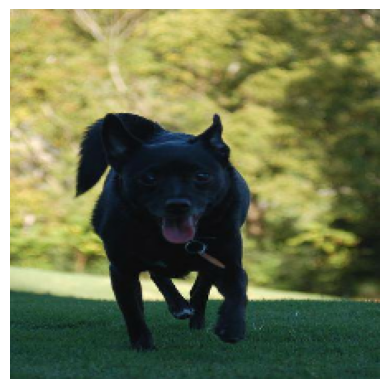

In [ ]:
plt.imshow(val_images[10])
plt.axis("off")

In [ ]:
def show_pred_label_and_image(prediction_probabilities, val_images = val_images , val_breeds=val_breeds , i = 1):
  pred_prob , image, breed = prediction_probabilities[i], val_images[i], val_breeds[i]
  breed_pred = get_breed_pred(pred_prob)
  probability = np.max(pred_prob) * 100
  plt.imshow(image)
  plt.axis("off")
  plt.xticks([])
  if(breed_pred == breed):
    color = "green"
  else:
    color = "red"
  plt.title(f"Prob: {probability:.2f}%,  Pred: {breed_pred} , true_breed: {breed}", color=color)

In [ ]:
np.max(prediction[0]) * 100, val_breeds[0]

(59.516578912734985, 'malamute')

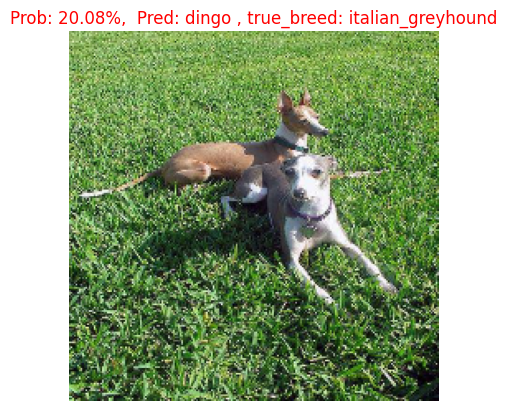

In [ ]:
show_pred_label_and_image(prediction, i = 80)

In [ ]:
def plot_pred_conf(prediction_probabilities, labels= val_breeds, n=1):
  pred_prob, true_breed = prediction_probabilities[n], labels[n]

  # Get the predicted label
  pred_breed = get_breed_pred(pred_prob)

  # Find the top 10 prediction confidence indexes
  top_10_pred_indexes = pred_prob.argsort()[-10:][::-1]
  # Find the top 10 prediction confidence values
  top_10_pred_values = pred_prob[top_10_pred_indexes]
  # Find the top 10 prediction labels
  top_10_pred_breeds = unique_breeds[top_10_pred_indexes]

  # Setup plot
  top_plot = plt.bar(np.arange(len(top_10_pred_breeds)),
                     top_10_pred_values,
                     color="grey")
  plt.xticks(np.arange(len(top_10_pred_breeds)),
             labels=top_10_pred_breeds,
             rotation="vertical")

  # Change color of true label
  if np.isin(true_breed, top_10_pred_breeds):
    top_plot[np.argmax(top_10_pred_breeds == true_breed)].set_color("green")
  else:
    pass

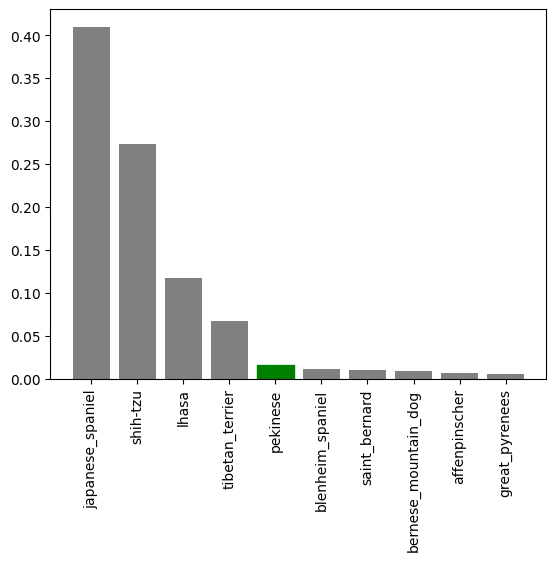

In [ ]:
plot_pred_conf(prediction, n = 7)

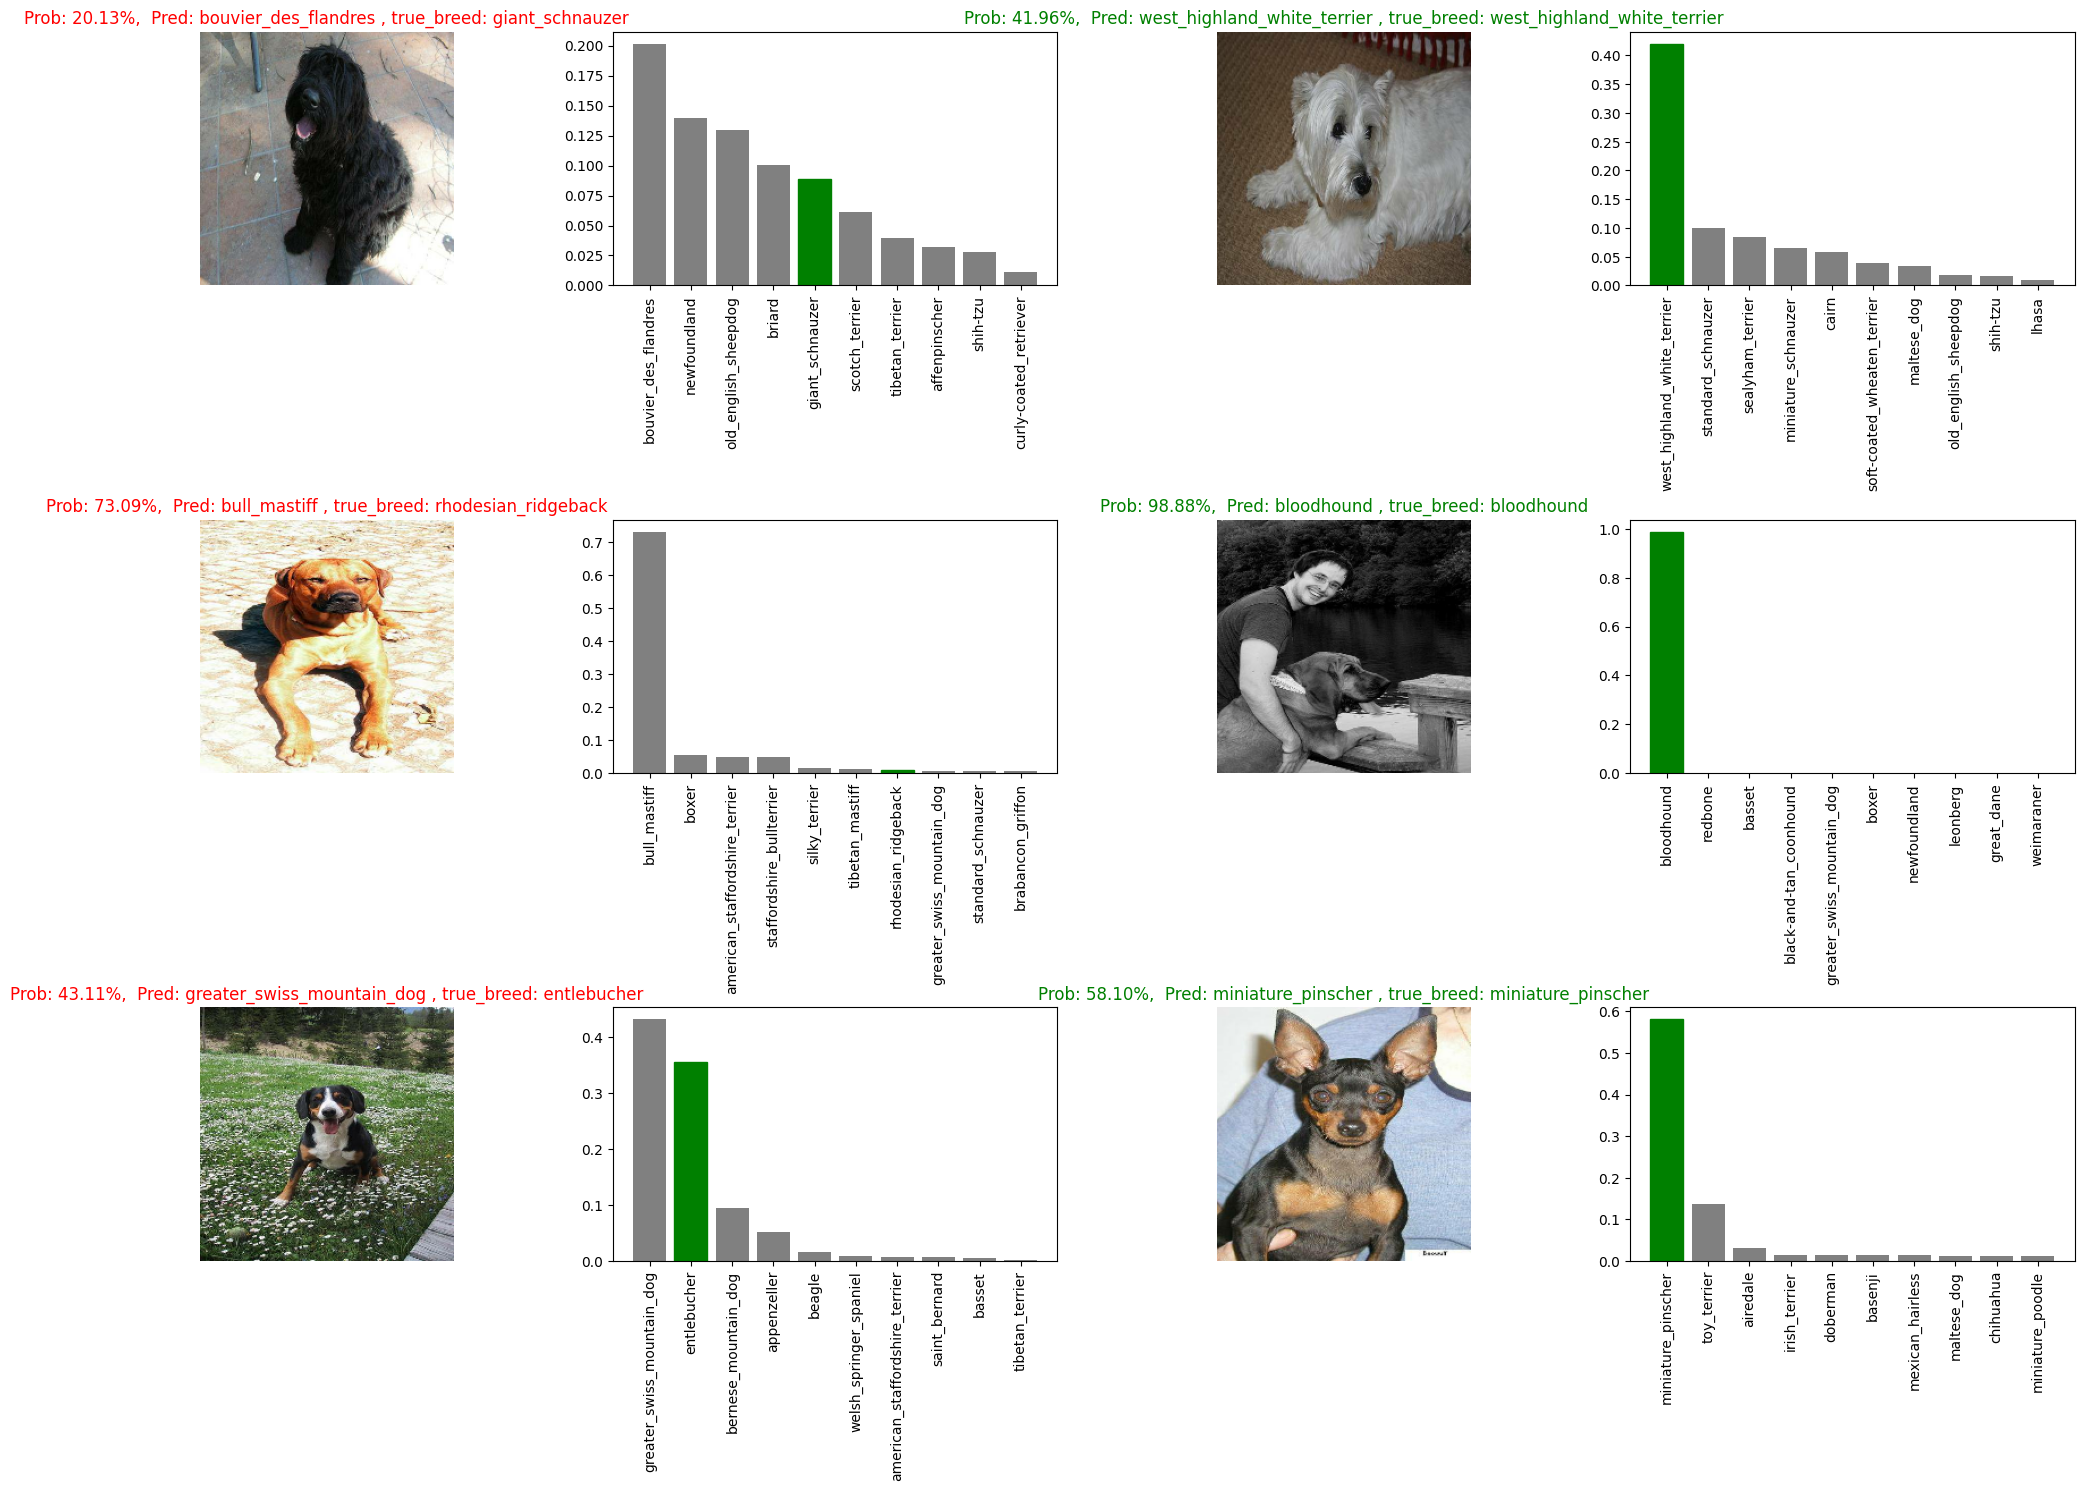

In [ ]:
i_multiplier = 20
num_rows = 3
num_cols = 2
num_images = num_rows*num_cols
plt.figure(figsize=(10*num_cols, 5*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  show_pred_label_and_image(prediction_probabilities=prediction,
            val_images=val_images,
            val_breeds=val_breeds,
            i=i+i_multiplier)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_pred_conf(prediction_probabilities=prediction,
                 labels=val_breeds,
                 n=i+i_multiplier)
plt.tight_layout(h_pad=1.0)
plt.show()

In [ ]:
def save_model(model ,  suffix=None):
  modeldir = os.path.join("drive/MyDrive/Dog-Breed-Identification/models", datetime.datetime.now().strftime("%y%m%d-%H%M%S"))
  model_path = modeldir + "-" + suffix + ".keras"
  model.save(model_path)
  return model_path

In [ ]:
def load_model(model_path):
  tf.keras.backend.clear_session()
  model = tf.keras.models.load_model(model_path,
                                     custom_objects={"KerasLayer":hub.KerasLayer},
                                     safe_mode=False,
                                     compile = False)
  return model

In [ ]:
# Saving model
save_model(model , suffix="1000-images-mobilenetv2-Adam")

'drive/MyDrive/Dog-Breed-Identification/models/241110-094940-1000-images-mobilenetv2-Adam.keras'

In [ ]:
model.evaluate(val_data)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 154ms/step - accuracy: 0.6893 - loss: 1.1788


[1.240739107131958, 0.675000011920929]

In [ ]:
len(X), len(y)

(10222, 10222)

### Creating batch of All images

In [ ]:
full_data = create_data_batches(X, y)

In [ ]:
full_data

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.bool, name=None))>

In [ ]:
test_path = "drive/MyDrive/Dog-Breed-Identification/test/"
test_filenames = [test_path +  fname for fname in os.listdir(test_path)]

In [ ]:
test_data = create_data_batches(test_filenames , test_data = True)

## Prediction the test data result

In [ ]:
test_predictions = full_model.predict(test_data , verbose = 1)

324/324 ━━━━━━━━━━━━━━━━━━━━ 250s 747ms/step


In [ ]:
np.savetxt("drive/MyDrive/Dog-Breed-Identification/test_predictions_final.csv", test_predictions , delimiter=',' )

In [ ]:
df = pd.read_csv('drive/MyDrive/Dog-Breed-Identification/test_predictions_final.csv')

In [ ]:
df

,9.745437963559755445e-13,1.603494420576723201e-11,8.922130612445955400e-13,6.752287097511189273e-12,2.147608306468651307e-11,7.870907398066506744e-11,4.419309360191407687e-14,1.323883919157609057e-10,3.412787208390000160e-08,6.680198061381759089e-10,...,6.923271417963450247e-12,6.994240690089137402e-12,1.403292571922065690e-06,3.174734786171029555e-07,2.504630114419370557e-10,1.466817292627986546e-11,2.170383447616663908e-12,5.985666823304924833e-11,8.674260094931884879e-12,1.254389508931197383e-10
0,7.939210e-09,6.159377e-10,2.005675e-08,2.137991e-10,1.725543e-06,1.553774e-06,9.343918e-10,3.815159e-08,7.978133e-07,8.453746e-01,...,1.283767e-08,9.109875e-08,1.572496e-08,2.569522e-06,1.328045e-06,4.576562e-10,2.946102e-09,1.540716e-09,4.777894e-08,2.170920e-08
1,1.104581e-08,1.073466e-11,1.284444e-08,5.871709e-11,1.635347e-09,1.514079e-09,8.142244e-10,6.285313e-10,4.806318e-11,3.453082e-08,...,4.083865e-07,1.913695e-05,9.758289e-10,2.155867e-10,1.004778e-11,8.061056e-10,4.946347e-09,3.901593e-12,4.432964e-09,4.033272e-06
2,1.782541e-08,1.578120e-07,4.314952e-09,3.030112e-08,4.631346e-08,1.213721e-07,3.897611e-08,2.404414e-07,1.577769e-04,1.279169e-01,...,4.576604e-11,1.611378e-08,5.708707e-07,9.263447e-04,2.832678e-08,9.363858e-08,5.702617e-09,3.315503e-08,2.511640e-07,1.412028e-08
3,2.338933e-09,2.300793e-08,1.930548e-07,7.259545e-04,2.462366e-09,1.198554e-08,2.361644e-04,4.223809e-07,1.218620e-07,4.887574e-09,...,1.400816e-07,5.857644e-07,7.641884e-07,1.414675e-07,3.061799e-09,4.970692e-07,1.250354e-05,6.507118e-07,2.196347e-05,6.106233e-06
4,3.559886e-11,7.469829e-12,2.828547e-11,9.282799e-12,2.415615e-09,2.763545e-12,4.629541e-12,2.682124e-12,3.457760e-14,7.130070e-09,...,2.276623e-12,2.763942e-11,5.779978e-10,3.220593e-12,4.484078e-11,2.126115e-14,1.917268e-14,8.337419e-10,4.283674e-13,1.269297e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10351,8.406243e-09,1.888218e-12,9.207682e-11,3.100657e-10,9.622823e-02,9.180133e-11,3.727048e-09,3.220192e-05,3.485886e-08,1.270067e-11,...,3.825327e-09,1.422534e-09,1.106935e-09,1.383573e-08,6.281321e-11,4.134031e-11,3.283827e-07,8.462772e-06,3.935203e-09,2.400260e-10
10352,4.168097e-11,2.982466e-11,1.691437e-09,2.055969e-10,1.557920e-07,2.007490e-09,2.403980e-09,1.086183e-08,1.263149e-08,1.554349e-08,...,1.658031e-10,1.241048e-10,1.856980e-08,3.374680e-08,2.700759e-06,4.494118e-11,5.767261e-11,3.850817e-08,4.997933e-10,6.275407e-13
10353,1.042370e-08,1.048054e-07,1.096820e-05,3.220317e-09,3.144959e-04,2.323215e-06,7.961458e-09,5.364395e-05,2.028761e-03,3.814878e-07,...,2.312853e-06,3.288089e-08,2.003186e-05,3.113017e-08,1.126217e-07,2.164633e-10,1.200756e-06,3.338026e-06,1.128378e-10,6.116861e-05
10354,1.341942e-07,1.193607e-11,6.043247e-11,5.788328e-10,5.422233e-09,3.641412e-09,1.225312e-09,1.639112e-08,4.315048e-09,8.849374e-10,...,4.324859e-10,2.055580e-09,2.161399e-09,1.153383e-10,6.698412e-09,5.546431e-11,1.621520e-09,4.546113e-09,3.602227e-11,1.158719e-10
